In [5]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

# Load the dataset and take top 5 rows in the dataset

In [6]:
kdd_cup99_dataset = pd.read_csv("kddcup99_csv.csv")
print(kdd_cup99_dataset.head())

   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   
2                     1.0                     0.0   
3           

# Check if dataset has empty rows or use describe

In [7]:

print(kdd_cup99_dataset.isnull().sum())
print(kdd_cup99_dataset.describe())

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
lnum_compromised               0
lroot_shell                    0
lsu_attempted                  0
lnum_root                      0
lnum_file_creations            0
lnum_shells                    0
lnum_access_files              0
lnum_outbound_cmds             0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

# Check if dataset has columns

In [8]:
print(kdd_cup99_dataset.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'lnum_compromised', 'lroot_shell',
       'lsu_attempted', 'lnum_root', 'lnum_file_creations', 'lnum_shells',
       'lnum_access_files', 'lnum_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label'],
      dtype='object')


# Check the shape and details of the dataset for training

In [9]:
print(kdd_cup99_dataset.shape)
print(kdd_cup99_dataset.info())

(494020, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  object 
 2   service                      494020 non-null  object 
 3   flag                         494020 non-null  object 
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   land                         494020 non-null  int64  
 7   wrong_fragment               494020 non-null  int64  
 8   urgent                       494020 non-null  int64  
 9   hot                          494020 non-null  int64  
 10  num_failed_logins            494020 non-null  int64  
 11  logged_in                    494020 non-null  int64  
 12  lnum_compromised             494020 non-null 

In [6]:
def Train_Test_SVMModel_Poly():
    X = kdd_cup99_dataset.drop('label', axis=1)
    y = kdd_cup99_dataset['label']
    
    encoder = LabelEncoder()
    columns = ['protocol_type','service','flag']
    for column in columns:
        X[column] = encoder.fit_transform(X[column])
        
    # Binary classification for specific attack types
    y_binary = np.where((y == 'smurf') | (y == 'teardrop') | (y == 'pod') | (y == 'neptune') | (y == 'land') | (y == 'back'), 1, -1)
    
    print('Original target distribution:', pd.Series(y_binary).value_counts(normalize=True))

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)
    
    undersampler = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

    print('Resampled target distribution:', pd.Series(y_train_resampled).value_counts(normalize=True))
    
    print(f"\nTraining and evaluating SVM model with poly kernel...")

    model = SVC(kernel='poly', degree=3)       
    model.fit(X_train_resampled, y_train_resampled)
       
    train_accuracy = model.score(X_train_resampled, y_train_resampled)
    test_accuracy = model.score(X_test, y_test)
    
    print(f"Training Accuracy with poly kernel: {train_accuracy:.4f}")
    print(f"Testing Accuracy with poly kernel: {test_accuracy:.4f}")

    y_pred = model.predict(X_test)
            
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for poly kernel:")
    print(cm)

    print(f"Classification Report for poly kernel:")
    print(classification_report(y_test, y_pred))

Train_Test_SVMModel_Poly()


Original target distribution:  1    0.792393
-1    0.207607
Name: proportion, dtype: float64
Resampled target distribution: -1    0.5
 1    0.5
Name: proportion, dtype: float64

Training and evaluating SVM model with poly kernel...
Training Accuracy with poly kernel: 0.9976
Testing Accuracy with poly kernel: 0.9965
Confusion Matrix for poly kernel:
[[20450     0]
 [  343 78011]]
Classification Report for poly kernel:
              precision    recall  f1-score   support

          -1       0.98      1.00      0.99     20450
           1       1.00      1.00      1.00     78354

    accuracy                           1.00     98804
   macro avg       0.99      1.00      0.99     98804
weighted avg       1.00      1.00      1.00     98804



In [7]:
def Train_Test_SVMModel_RBF():
    X = kdd_cup99_dataset.drop('label', axis=1)
    y = kdd_cup99_dataset['label']
    
    encoder = LabelEncoder()
    columns = ['protocol_type','service','flag']
    for column in columns:
        X[column] = encoder.fit_transform(X[column])
        
    # Binary classification for specific attack types
    y_binary = np.where((y == 'smurf') | (y == 'teardrop') | (y == 'pod') | (y == 'neptune') | (y == 'land') | (y == 'back'), 1, -1)
    
    print('Original target distribution:', pd.Series(y_binary).value_counts(normalize=True))

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)
    
    undersampler = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

    print('Resampled target distribution:', pd.Series(y_train_resampled).value_counts(normalize=True))
    
    print(f"\nTraining and evaluating SVM model with rbf kernel...")

    model = SVC(kernel='rbf')       
    model.fit(X_train_resampled, y_train_resampled)
       
    train_accuracy = model.score(X_train_resampled, y_train_resampled)
    test_accuracy = model.score(X_test, y_test)
    
    print(f"Training Accuracy with rbf kernel: {train_accuracy:.4f}")
    print(f"Testing Accuracy with rbf kernel: {test_accuracy:.4f}")

    y_pred = model.predict(X_test)
            
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for rbf kernel:")
    print(cm)

    print(f"Classification Report for rbf kernel:")
    print(classification_report(y_test, y_pred))

Train_Test_SVMModel_RBF()


Original target distribution:  1    0.792393
-1    0.207607
Name: proportion, dtype: float64
Resampled target distribution: -1    0.5
 1    0.5
Name: proportion, dtype: float64

Training and evaluating SVM model with rbf kernel...
Training Accuracy with rbf kernel: 0.9969
Testing Accuracy with rbf kernel: 0.9953
Confusion Matrix for rbf kernel:
[[20450     0]
 [  462 77892]]
Classification Report for rbf kernel:
              precision    recall  f1-score   support

          -1       0.98      1.00      0.99     20450
           1       1.00      0.99      1.00     78354

    accuracy                           1.00     98804
   macro avg       0.99      1.00      0.99     98804
weighted avg       1.00      1.00      1.00     98804



In [8]:
def Train_Test_SVMModel_Linear():
    X = kdd_cup99_dataset.drop('label', axis=1)
    y = kdd_cup99_dataset['label']
    
    encoder = LabelEncoder()
    columns = ['protocol_type','service','flag']
    for column in columns:
        X[column] = encoder.fit_transform(X[column])
        
    # Binary classification for specific attack types
    y_binary = np.where((y == 'smurf') | (y == 'teardrop') | (y == 'pod') | (y == 'neptune') | (y == 'land') | (y == 'back'), 1, -1)
    
    print('Original target distribution:', pd.Series(y_binary).value_counts(normalize=True))

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)
    
    undersampler = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

    print('Resampled target distribution:', pd.Series(y_train_resampled).value_counts(normalize=True))
    
    print(f"\nTraining and evaluating SVM model with linear kernel...")

    model = SVC(kernel='linear')       
    model.fit(X_train_resampled, y_train_resampled)
       
    train_accuracy = model.score(X_train_resampled, y_train_resampled)
    test_accuracy = model.score(X_test, y_test)
    
    print(f"Training Accuracy with linear kernel: {train_accuracy:.4f}")
    print(f"Testing Accuracy with linear kernel: {test_accuracy:.4f}")

    y_pred = model.predict(X_test)
            
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for linear kernel:")
    print(cm)

    print(f"Classification Report for linear kernel:")
    print(classification_report(y_test, y_pred))
    return model,X_train_resampled,y_train_resampled,X_test,y_test,X.columns

Train_Test_SVMModel_Linear()


Original target distribution:  1    0.792393
-1    0.207607
Name: proportion, dtype: float64
Resampled target distribution: -1    0.5
 1    0.5
Name: proportion, dtype: float64

Training and evaluating SVM model with linear kernel...
Training Accuracy with linear kernel: 0.9963
Testing Accuracy with linear kernel: 0.9949
Confusion Matrix for linear kernel:
[[20431    19]
 [  483 77871]]
Classification Report for linear kernel:
              precision    recall  f1-score   support

          -1       0.98      1.00      0.99     20450
           1       1.00      0.99      1.00     78354

    accuracy                           0.99     98804
   macro avg       0.99      1.00      0.99     98804
weighted avg       1.00      0.99      0.99     98804



(SVC(kernel='linear'),
 array([[0.        , 0.5       , 0.33846154, ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.5       , 0.33846154, ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.5       , 0.33846154, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.21538462, ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.5       , 0.69230769, ..., 1.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.21538462, ..., 0.        , 0.        ,
         0.        ]]),
 array([-1, -1, -1, ...,  1,  1,  1]),
 array([[0.        , 0.        , 0.21538462, ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.21538462, ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.5       , 0.69230769, ..., 1.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.5       , 0.33846154, .

In [26]:
def Train_Test_SVMModel_Sigmoid():

    X = kdd_cup99_dataset.drop('label', axis=1)
    y = kdd_cup99_dataset['label']
    
    encoder = LabelEncoder()
    columns = ['protocol_type','service','flag']
    for column in columns:
        X[column] = encoder.fit_transform(X[column])
        
    # Binary classification for specific attack types
    y_binary = np.where((y == 'smurf') | (y == 'teardrop') | (y == 'pod') | (y == 'neptune') | (y == 'land') | (y == 'back'), 1, -1)
    
    print('Original target distribution:', pd.Series(y_binary).value_counts(normalize=True))

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)
    
    undersampler = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

    print('Resampled target distribution:', pd.Series(y_train_resampled).value_counts(normalize=True))
    
    print(f"\nTraining and evaluating SVM model with sigmoid kernel...")

    model = SVC(kernel='sigmoid')       
    model.fit(X_train_resampled, y_train_resampled)
       
    train_accuracy = model.score(X_train_resampled, y_train_resampled)
    test_accuracy = model.score(X_test, y_test)
    
    print(f"Training Accuracy with sigmoid kernel: {train_accuracy:.4f}")
    print(f"Testing Accuracy with sigmoid kernel: {test_accuracy:.4f}")

    y_pred = model.predict(X_test)
            
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for sigmoid kernel:")
    print(cm)

    print(f"Classification Report for sigmoid kernel:")
    print(classification_report(y_test, y_pred))

Train_Test_SVMModel_Sigmoid()


Original target distribution:  1    0.792393
-1    0.207607
Name: proportion, dtype: float64
Resampled target distribution: -1    0.5
 1    0.5
Name: proportion, dtype: float64

Training and evaluating SVM model with sigmoid kernel...
Training Accuracy with sigmoid kernel: 0.9333
Testing Accuracy with sigmoid kernel: 0.9354
Confusion Matrix for sigmoid kernel:
[[19045  1405]
 [ 4973 73381]]
Classification Report for sigmoid kernel:
              precision    recall  f1-score   support

          -1       0.79      0.93      0.86     20450
           1       0.98      0.94      0.96     78354

    accuracy                           0.94     98804
   macro avg       0.89      0.93      0.91     98804
weighted avg       0.94      0.94      0.94     98804



Based on the above results for the SVM model trained using each kernel they are as follows 
1. For the Polynomial Kernel: It has the highest accuracy 99.65% as compared to others and overall performance is also very good.
This kernel is used and is very Excellent for capturing complex, non-linear relationships as well.
The major cons are that the is computationally costly, especially for higher degrees. The usage of this kernel might overfit on small datasets.
2. For the RBF Kernel: The overall accuracy is 99.53% which has a very close performance to the polynomial kernel.
Very close performance to the polynomial kernel. It is very effective for a wide range of problems
It generally performs well when the number of features is quite small compared to the number of instances. The cons are that it struggles with very high-dimensional data.
3. For the Linear Kernel: It's the simplest type of kernel and computation time is the fastest and the overall accuracy being 99.49%. It performs nearly as well as more complex kernels in comparison and it's very easy to interpret. The major cons as the name suggests that it has limited ability to capture the non-linear relationships in data and it might underperform on more complex datasets.
May underperform on more complex datasets
4. For the Sigmoid Kernel: The overall accuracy is lower as compared to other kernels which is 93.54%. It can actually handle non-linear relationships and be used in neural networks. The major con here is that it has significantly lower performance as compared to other kernels in this particular dataset, and it is often very sensitive to the scaling of features and choices of hyperparameters.

Thus, For this specific dataset, the polynomial kernel is overall providing the best performance, which is closely followed by the RBF and linear kernels. The choice between these three kernels would majorly depend on various factors such as computational resources, interpretability needs, and the specific characteristics in the data.
The sigmoid kernel's not very good performance suggests it might not be suitable for this particular problem. The usage might be more appropriate in other contexts or with different hyperparameter settings.
Given the very high performance of the linear kernel, it's definitely worth considering whether or not the addition in complexity of non-linear kernels is necessary for this dataset.
The linear kernel thus offers a very good balance of performance and simplicity, which could be beneficial in many practical applications.


# Find the feature and weight sorted by descending to find important features

In [15]:
def important_features_weight():
    model,X_train_resampled,y_train_resampled,X_test,y_test,X_cols = Train_Test_SVMModel_Linear()
    features = X_cols
    weights = abs(model.coef_[0])
    
    min_length = min(len(features), len(weights))
    features = features[:min_length]
    weights = weights[:min_length]
    
    df_weight = pd.DataFrame({'Feature':X_cols, 'Weight': weights})
    weights_df_sorting = df_weight.sort_values(by='Weight', ascending=False)
    print(weights_df_sorting)
important_features_weight()


Original target distribution:  1    0.792393
-1    0.207607
Name: proportion, dtype: float64
Resampled target distribution: -1    0.5
 1    0.5
Name: proportion, dtype: float64

Training and evaluating SVM model with linear kernel...
Training Accuracy with linear kernel: 0.9963
Testing Accuracy with linear kernel: 0.9949
Confusion Matrix for linear kernel:
[[20431    19]
 [  483 77871]]
Classification Report for linear kernel:
              precision    recall  f1-score   support

          -1       0.98      1.00      0.99     20450
           1       1.00      0.99      1.00     78354

    accuracy                           0.99     98804
   macro avg       0.99      1.00      0.99     98804
weighted avg       1.00      0.99      0.99     98804

                        Feature     Weight
9                           hot  12.551280
21               is_guest_login  11.183694
7                wrong_fragment   8.208830
28                same_srv_rate   2.963647
29                diff_srv_

Original target distribution:  1    0.792393
-1    0.207607
Name: proportion, dtype: float64
Resampled target distribution: -1    0.5
 1    0.5
Name: proportion, dtype: float64

Training and evaluating SVM model with linear kernel...
Training Accuracy with linear kernel: 0.9963
Testing Accuracy with linear kernel: 0.9949
Confusion Matrix for linear kernel:
[[20431    19]
 [  483 77871]]
Classification Report for linear kernel:
              precision    recall  f1-score   support

          -1       0.98      1.00      0.99     20450
           1       1.00      0.99      1.00     78354

    accuracy                           0.99     98804
   macro avg       0.99      1.00      0.99     98804
weighted avg       1.00      0.99      0.99     98804



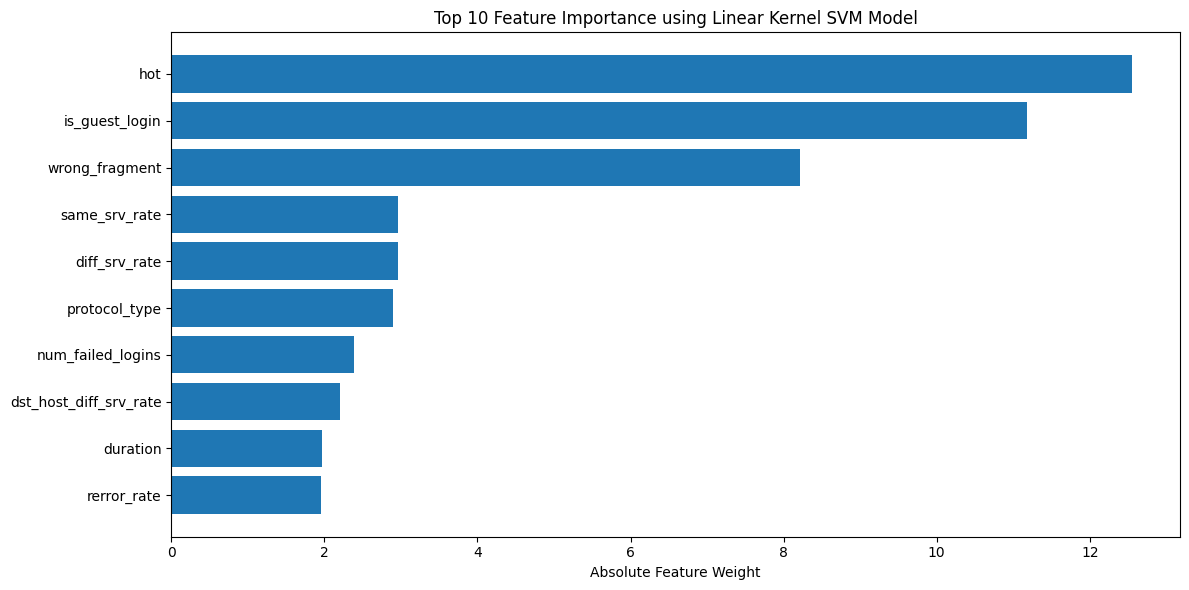

In [16]:
def Feature_imp_trained_weights():
    model,X_train_resampled,y_train_resampled,X_test,y_test,X_cols = Train_Test_SVMModel_Linear()
    
    feature_importance = abs(model.coef_[0])
    
    valid_indices = np.where(np.arange(len(feature_importance)) < len(X_cols))[0]
    feature_importance = feature_importance[valid_indices]
    
    n_top_features = min(10, len(feature_importance))
    sorted_idx = np.argsort(feature_importance)[-n_top_features:]
    
    pos = np.arange(len(sorted_idx)) + 0.5
    
    plt.figure(figsize=(12, 6))
    plt.barh(pos, feature_importance[sorted_idx], align='center')
    plt.yticks(pos, [X_cols[i] for i in sorted_idx])
    plt.xlabel('Absolute Feature Weight')
    plt.title(f'Top {n_top_features} Feature Importance using Linear Kernel SVM Model')
    plt.tight_layout()
    plt.show()

Feature_imp_trained_weights()

# SVM model evaluation using 2 important features in the dataset calculated above using linear kernel 

Original target distribution:  1    0.792822
-1    0.207178
Name: proportion, dtype: float64
Resampled target distribution: -1    0.5
 1    0.5
Name: proportion, dtype: float64

Training and evaluating SVM model with linear kernel...
Training Accuracy with linear kernel: 0.5031
Testing Accuracy with linear kernel: 0.7989
Confusion Matrix for linear kernel:
[[  18 1987]
 [   0 7876]]
Classification Report for linear kernel:
              precision    recall  f1-score   support

          -1       1.00      0.01      0.02      2005
           1       0.80      1.00      0.89      7876

    accuracy                           0.80      9881
   macro avg       0.90      0.50      0.45      9881
weighted avg       0.84      0.80      0.71      9881



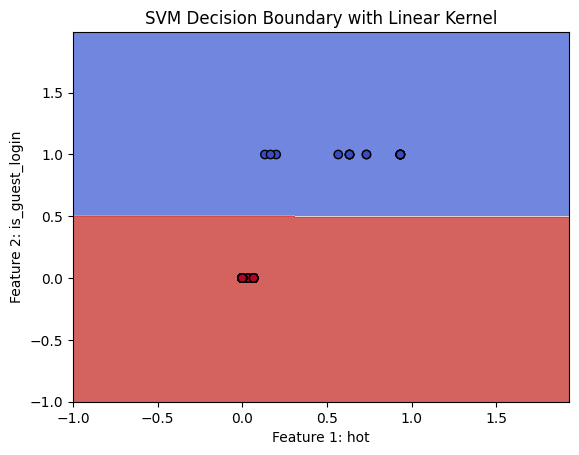

In [3]:
kdd_cup99_sample = kdd_cup99_dataset.sample(frac=0.1, random_state=42)
X = kdd_cup99_sample[['hot', 'is_guest_login']].values
y = kdd_cup99_sample['label'].values
    
# Binary classification for specific attack types
y_binary = np.where((y == 'smurf') | (y == 'teardrop') | (y == 'pod') | (y == 'neptune') | (y == 'land') | (y == 'back'), 1, -1)

print('Original target distribution:', pd.Series(y_binary).value_counts(normalize=True))

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

undersampler = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

print('Resampled target distribution:', pd.Series(y_train_resampled).value_counts(normalize=True))

print(f"\nTraining and evaluating SVM model with linear kernel...")

model = SVC(kernel='linear')       
model.fit(X_train_resampled, y_train_resampled)
   
train_accuracy = model.score(X_train_resampled, y_train_resampled)
test_accuracy = model.score(X_test, y_test)

print(f"Training Accuracy with linear kernel: {train_accuracy:.4f}")
print(f"Testing Accuracy with linear kernel: {test_accuracy:.4f}")

y_pred = model.predict(X_test)
        
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix for linear kernel:")
print(cm)

print(f"Classification Report for linear kernel:")
print(classification_report(y_test, y_pred))


def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1: hot')
    plt.ylabel('Feature 2: is_guest_login')
    plt.title('SVM Decision Boundary with Linear Kernel')
    plt.show()

model = SVC(kernel='linear') 
model.fit(X_train_resampled, y_train_resampled)

plot_decision_boundary(X_test, y_test, model)



To train an SVM model used only two features and visualized the decision boundary, For which I selected the top two features based on their weights using a linear kernel. In this case, the features are: Feature 1 and Feature2 hot (Weight: 12.551280) and is_guest_login (Weight: 11.183694) respectively, For the linear kernel the decision boundary used produces a straight line separating the classes and making The linear boundary easy to interpret and indicating a simple relationship between the features. Thus, it might perform well if the data is linearly separable. It is ideal for simpler, linearly separable datasets where interpretability and computational efficiency are priorities.

# SVM model evaluation using 2 important features in the dataset calculated above using rbf kernel 

Original target distribution:  1    0.792822
-1    0.207178
Name: proportion, dtype: float64
Resampled target distribution: -1    0.5
 1    0.5
Name: proportion, dtype: float64

Training and evaluating SVM model with rbf kernel...
Training Accuracy with rbf kernel: 0.5032
Testing Accuracy with rbf kernel: 0.7989
Confusion Matrix for rbf kernel:
[[  18 1987]
 [   0 7876]]
Classification Report for rbf kernel:
              precision    recall  f1-score   support

          -1       1.00      0.01      0.02      2005
           1       0.80      1.00      0.89      7876

    accuracy                           0.80      9881
   macro avg       0.90      0.50      0.45      9881
weighted avg       0.84      0.80      0.71      9881



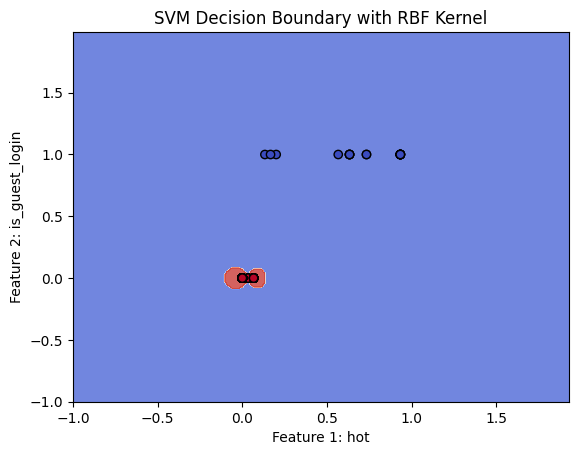

In [4]:
kdd_cup99_sample = kdd_cup99_dataset.sample(frac=0.1, random_state=42)
X = kdd_cup99_sample[['hot', 'is_guest_login']].values
y = kdd_cup99_sample['label'].values
    
y_binary = np.where((y == 'smurf') | (y == 'teardrop') | (y == 'pod') | (y == 'neptune') | (y == 'land') | (y == 'back'), 1, -1)

print('Original target distribution:', pd.Series(y_binary).value_counts(normalize=True))

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

undersampler = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

print('Resampled target distribution:', pd.Series(y_train_resampled).value_counts(normalize=True))

print(f"\nTraining and evaluating SVM model with rbf kernel...")

model = SVC(kernel='rbf')       
model.fit(X_train_resampled, y_train_resampled)
   
train_accuracy = model.score(X_train_resampled, y_train_resampled)
test_accuracy = model.score(X_test, y_test)

print(f"Training Accuracy with rbf kernel: {train_accuracy:.4f}")
print(f"Testing Accuracy with rbf kernel: {test_accuracy:.4f}")

y_pred = model.predict(X_test)
        
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix for rbf kernel:")
print(cm)

print(f"Classification Report for rbf kernel:")
print(classification_report(y_test, y_pred))

def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1: hot')
    plt.ylabel('Feature 2: is_guest_login')
    plt.title('SVM Decision Boundary with RBF Kernel')
    plt.show()

model = SVC(kernel='rbf') 
model.fit(X_train_resampled, y_train_resampled)

plot_decision_boundary(X_test, y_test, model)


To train an SVM model used only two features and visualized the decision boundary, For which I selected the top two features based on their weights. In this case, the features are: Feature 1 and Feature2 hot (Weight: 12.551280) and is_guest_login (Weight: 11.183694) respectively, For the RBF kernel it creates a complex, non-linear decision boundary, which can effectively separate classes that are not linearly separable. This boundary basically adapts to the data's distribution, thereby capturing more intricate patterns. The decision regions are more curved and localized around the data points, indicating the RBF kernel's ability to model complex relationships.
It is suitable for capturing non-linear patterns and interactions between features. It can be more effective when the data's structure is complex.